In [7]:
import os
from dotenv import load_dotenv

load_dotenv()

source_dir = os.getenv("RAW_DATA_PATH")
source_dir_norm = os.getenv("RAW_DATA_PATH_norm")
target_dir = os.getenv("CLEANED_DATA_PATH")

print("Paths loaded securely!")

Paths loaded securely!


In [9]:
import os
import cv2
import numpy as np

widths, heights = [], []
path = source_dir_norm

for img_name in os.listdir(path):
    img = cv2.imread(os.path.join(path, img_name))
    if img is not None:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

print(f"Average Resolution: {int(np.mean(widths))}x{int(np.mean(heights))}")
print(f"Min Resolution: {np.min(widths)}x{np.min(heights)}")
print(f"Max Resolution: {np.max(widths)}x{np.max(heights)}")

Average Resolution: 1667x1381
Min Resolution: 912x672
Max Resolution: 2916x2663


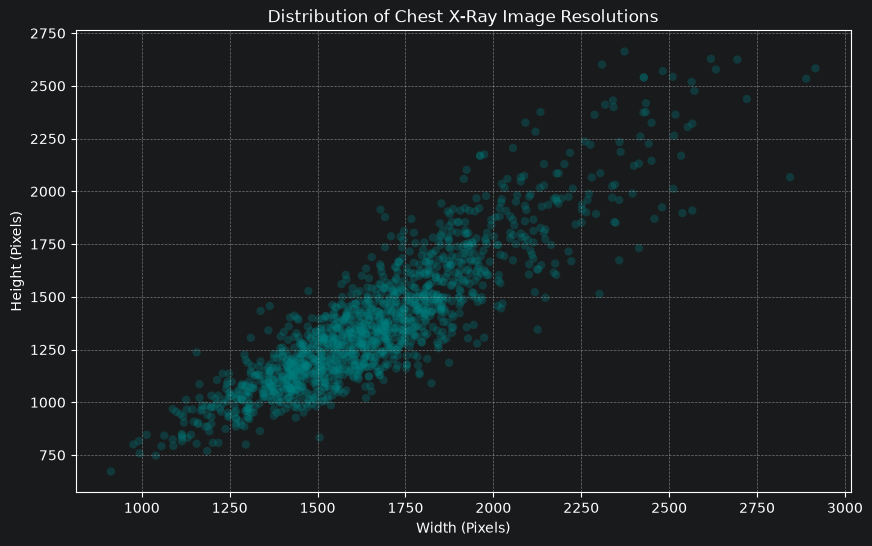

Width Standard Deviation: 289
Height Standard Deviation: 326


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, alpha=0.3, color='teal', edgecolors='none')

plt.title("Distribution of Chest X-Ray Image Resolutions")
plt.xlabel("Width (Pixels)")
plt.ylabel("Height (Pixels)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Width Standard Deviation: {int(np.std(widths))}")
print(f"Height Standard Deviation: {int(np.std(heights))}")

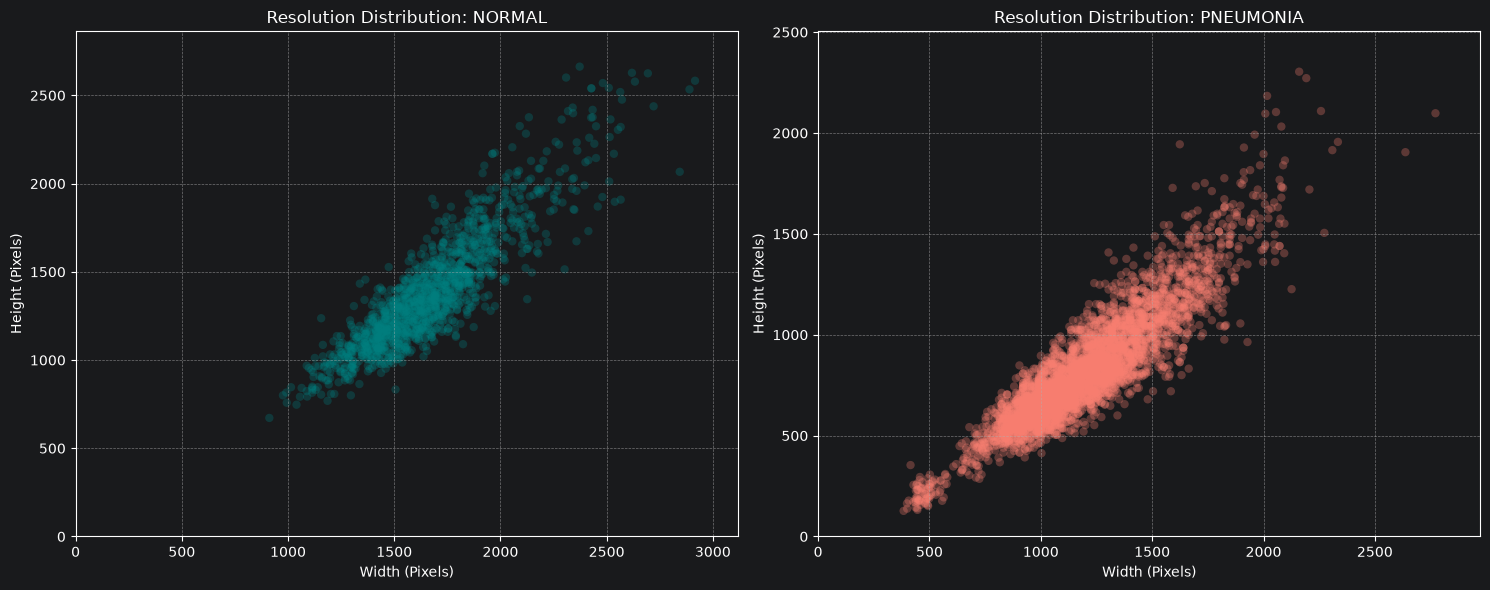

In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

base_dir = source_dir
categories = ['NORMAL', 'PNEUMONIA']
colors = ['teal', 'salmon']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, category in enumerate(categories):
    path = os.path.join(base_dir, category)
    widths = []
    heights = []

    for img_name in os.listdir(path):
        img = cv2.imread(os.path.join(path, img_name))
        if img is not None:
            heights.append(img.shape[0])
            widths.append(img.shape[1])

    axes[i].scatter(widths, heights, alpha=0.3, color=colors[i], edgecolors='none')
    axes[i].set_title(f"Resolution Distribution: {category}")
    axes[i].set_xlabel("Width (Pixels)")
    axes[i].set_ylabel("Height (Pixels)")
    axes[i].grid(True, linestyle='--', alpha=0.6)

    axes[i].set_xlim(0, max(widths) + 200)
    axes[i].set_ylim(0, max(heights) + 200)

plt.tight_layout()
plt.show()

--- NORMAL ---
Median AR: 1.223
Min AR: 0.877 | Max AR: 1.808
--- PNEUMONIA ---
Median AR: 1.488
Min AR: 0.835 | Max AR: 3.379


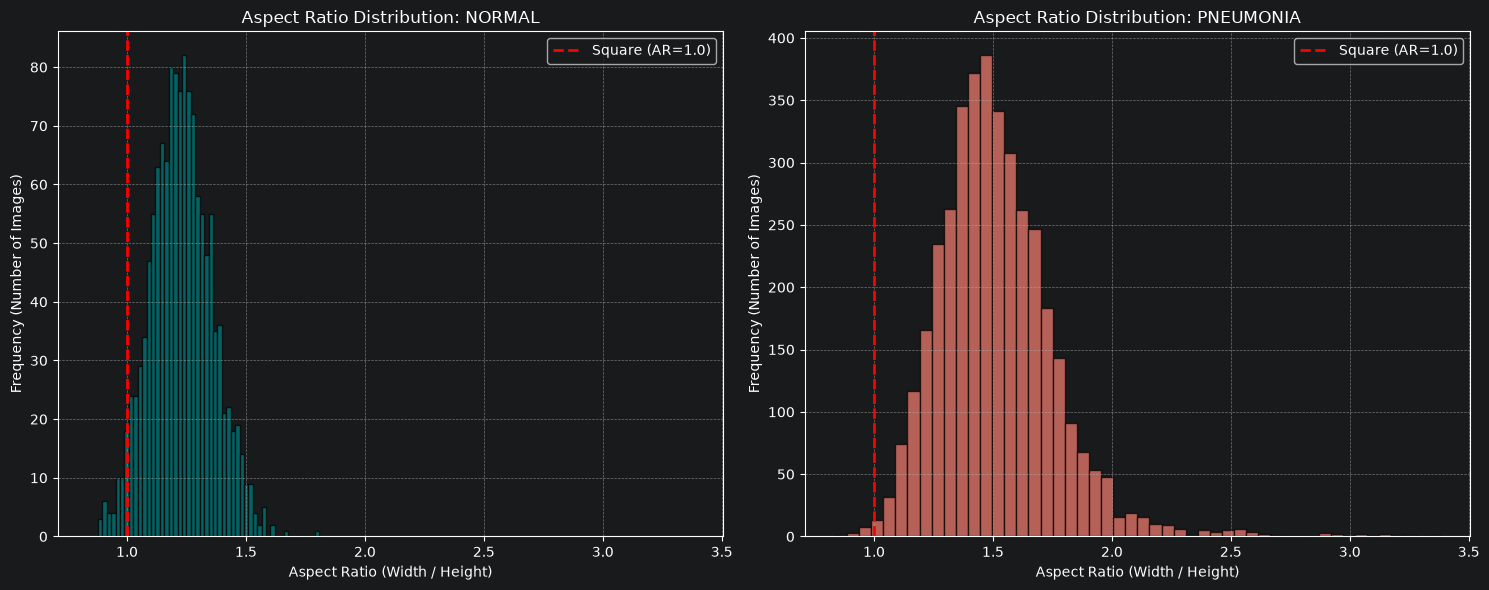

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

base_dir = source_dir
categories = ['NORMAL', 'PNEUMONIA']
colors = ['teal', 'salmon']

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

for i, category in enumerate(categories):
    path = os.path.join(base_dir, category)
    aspect_ratios = []

    for img_name in os.listdir(path):
        img = cv2.imread(os.path.join(path, img_name))
        if img is not None:
            h, w = img.shape[:2]
            ar = w / h
            aspect_ratios.append(ar)

    axes[i].hist(aspect_ratios, bins=50, color=colors[i], alpha=0.7, edgecolor='black')
    axes[i].set_title(f"Aspect Ratio Distribution: {category}")
    axes[i].set_xlabel("Aspect Ratio (Width / Height)")
    axes[i].set_ylabel("Frequency (Number of Images)")

    axes[i].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Square (AR=1.0)')

    print(f"--- {category} ---")
    print(f"Median AR: {np.median(aspect_ratios):.3f}")
    print(f"Min AR: {np.min(aspect_ratios):.3f} | Max AR: {np.max(aspect_ratios):.3f}")

    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [14]:
import cv2
import numpy as np
import shutil

def get_scientific_bounds(data_list):
    q1 = np.percentile(data_list, 25)
    q3 = np.percentile(data_list, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return lower_bound, upper_bound

categories = ['NORMAL', 'PNEUMONIA']

for category in categories:
    src_path = os.path.join(source_dir, category)

    widths, heights, aspect_ratios = [], [], []
    valid_images = []

    for img_name in os.listdir(src_path):
        img_path = os.path.join(src_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w = img.shape[:2]
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
            valid_images.append((img_name, w, h, w / h))

    w_lower, w_upper = get_scientific_bounds(widths)
    h_lower, h_upper = get_scientific_bounds(heights)
    ar_lower, ar_upper = get_scientific_bounds(aspect_ratios)

    print(f"\n--- Scientific Thresholds for {category} ---")
    print(f"Valid Width: {int(w_lower)} to {int(w_upper)} px")
    print(f"Valid Height: {int(h_lower)} to {int(h_upper)} px")
    print(f"Valid Aspect Ratio: {ar_lower:.2f} to {ar_upper:.2f}")

    tgt_path = os.path.join(target_dir, category)
    os.makedirs(tgt_path, exist_ok=True)

    kept, dropped = 0, 0
    for img_name, w, h, ar in valid_images:
        if (w_lower <= w <= w_upper) and (h_lower <= h <= h_upper) and (ar_lower <= ar <= ar_upper):
            shutil.copy(os.path.join(src_path, img_name), os.path.join(tgt_path, img_name))
            kept += 1
        else:
            dropped += 1

    print(f"Action: Kept {kept} images, Dropped {dropped} outliers.")


--- Scientific Thresholds for NORMAL ---
Valid Width: 929 to 2361 px
Valid Height: 567 to 2127 px
Valid Aspect Ratio: 0.88 to 1.57
Action: Kept 1277 images, Dropped 64 outliers.

--- Scientific Thresholds for PNEUMONIA ---
Valid Width: 448 to 1920 px
Valid Height: 148 to 1460 px
Valid Aspect Ratio: 0.92 to 2.08
Action: Kept 3654 images, Dropped 221 outliers.


In [15]:
import os
import cv2
import numpy as np
import shutil


def get_scientific_bounds(data_list):
    q1 = np.percentile(data_list, 25)
    q3 = np.percentile(data_list, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return lower_bound, upper_bound

categories = ['NORMAL', 'PNEUMONIA']

global_widths, global_heights, global_ars = [], [], []
all_images_data = []

print("Step 1: Analyzing global dataset...")

for category in categories:
    src_path = os.path.join(source_dir, category)
    for img_name in os.listdir(src_path):
        img_path = os.path.join(src_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w = img.shape[:2]
            ar = w / h
            global_widths.append(w)
            global_heights.append(h)
            global_ars.append(ar)
            all_images_data.append((category, img_name, w, h, ar))

w_lower, w_upper = get_scientific_bounds(global_widths)
h_lower, h_upper = get_scientific_bounds(global_heights)
ar_lower, ar_upper = get_scientific_bounds(global_ars)

print("\n--- GLOBAL SCIENTIFIC THRESHOLDS ---")
print(f"Unified Width: {int(w_lower)} to {int(w_upper)} px")
print(f"Unified Height: {int(h_lower)} to {int(h_upper)} px")
print(f"Unified Aspect Ratio: {ar_lower:.2f} to {ar_upper:.2f}")

print("\nStep 2: Applying unified filters...")

stats = {cat: {'kept': 0, 'dropped': 0} for cat in categories}

for category, img_name, w, h, ar in all_images_data:
    src_path = os.path.join(source_dir, category)
    tgt_path = os.path.join(target_dir, category)
    os.makedirs(tgt_path, exist_ok=True)

    if (w_lower <= w <= w_upper) and (h_lower <= h <= h_upper) and (ar_lower <= ar <= ar_upper):
        shutil.copy(os.path.join(src_path, img_name), os.path.join(tgt_path, img_name))
        stats[category]['kept'] += 1
    else:
        stats[category]['dropped'] += 1

print("\n--- FINAL REPORT ---")
for cat in categories:
    kept = stats[cat]['kept']
    dropped = stats[cat]['dropped']
    total = kept + dropped
    print(f"{cat}: Kept {kept}, Dropped {dropped} ({(dropped/total)*100:.1f}%)")

Step 1: Analyzing global dataset...

--- GLOBAL SCIENTIFIC THRESHOLDS ---
Unified Width: 312 to 2296 px
Unified Height: -61 to 1937 px
Unified Aspect Ratio: 0.77 to 2.07

Step 2: Applying unified filters...

--- FINAL REPORT ---
NORMAL: Kept 1247, Dropped 94 (7.0%)
PNEUMONIA: Kept 3772, Dropped 103 (2.7%)


In [17]:
import os
import cv2
from dotenv import load_dotenv

load_dotenv()

clean_data_dir = target_dir
resized_data_dir = os.getenv("RESIZED_DATA_PATH")

if clean_data_dir is None or resized_data_dir is None:
    raise ValueError("Error: Paths are not set properly in the .env file!")

TARGET_SIZE = (224, 224)
categories = ['NORMAL', 'PNEUMONIA']

print(f"Starting direct resize to {TARGET_SIZE}...\n")

for category in categories:
    src_path = os.path.join(clean_data_dir, category)
    tgt_path = os.path.join(resized_data_dir, category)

    os.makedirs(tgt_path, exist_ok=True)

    count = 0
    for img_name in os.listdir(src_path):
        img_path = os.path.join(src_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            img_resized = cv2.resize(img, TARGET_SIZE)

            cv2.imwrite(os.path.join(tgt_path, img_name), img_resized)
            count += 1

    print(f"--- {category} ---")
    print(f"Processed and saved {count} images.")

print("\nDataset creation complete! direct-resized dataset is ready.")

Starting direct resize to (224, 224)...

--- NORMAL ---
Processed and saved 1287 images.
--- PNEUMONIA ---
Processed and saved 3775 images.

Dataset creation complete! direct-resized dataset is ready.
